In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [4]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [6]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [7]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [8]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [9]:
# fetch where value is null
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] 

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Age_imputed, Length: 148, dtype: float64

In [10]:
# random sample imputation for 
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([18.  , 33.  , 42.  , 17.  , 22.  , 27.  , 32.  , 38.  , 21.  ,
       31.  , 11.  , 48.  , 30.  , 25.  , 27.  , 23.  , 23.  , 36.  ,
       22.  , 18.  , 28.  , 24.  , 35.  , 47.  , 30.  , 28.  , 56.  ,
       30.  , 21.  ,  9.  , 18.  , 25.  , 31.  , 31.  , 32.5 , 29.  ,
       30.  , 31.  , 22.  ,  4.  , 28.  , 32.  , 30.  , 24.  , 13.  ,
       34.5 , 28.  , 26.  , 35.  , 62.  , 28.  , 58.  , 14.  , 26.  ,
       33.  , 29.  ,  0.83, 24.  , 23.  , 41.  , 26.  , 39.  ,  1.  ,
       46.  , 34.  ,  4.  , 48.  , 27.  , 42.  , 59.  , 48.  , 38.  ,
       33.  , 30.  , 33.  , 39.  , 19.  , 62.  , 44.  , 54.  , 16.  ,
       21.  , 35.  , 25.  , 61.  , 28.5 , 27.  , 25.  , 16.  , 39.  ,
       19.  , 37.  , 18.  , 39.  , 16.  , 22.  , 45.  ,  5.  , 23.  ,
       50.  , 40.5 , 21.  , 29.  , 54.  , 30.  , 22.  , 36.  , 52.  ,
       21.  , 26.  ,  0.67, 36.  , 47.  , 29.  , 24.  , 24.  , 27.  ,
       37.  , 25.  , 18.  , 31.  , 46.  , 37.  , 22.  , 54.  , 30.  ,
       14.5 , 27.  ,

In [11]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [12]:
X_train['Age'].isnull().sum()

148

In [13]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,27.0
493,71.0,49.5042,71.0
527,NaN,221.7792,26.0


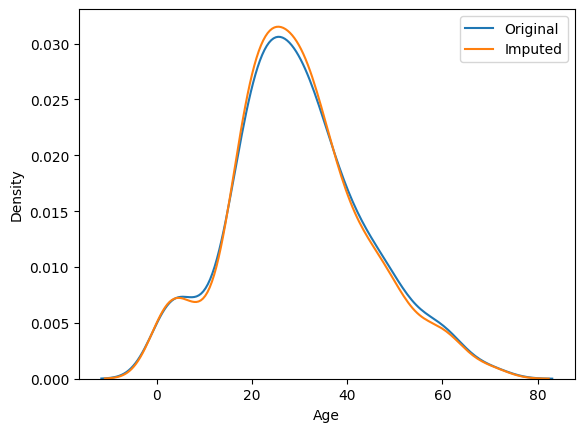

In [ ]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [23]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  197.47450223435104


In [ ]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,60.668974
Age,71.512440,204.349513,204.349513
Age_imputed,60.668974,204.349513,197.474502


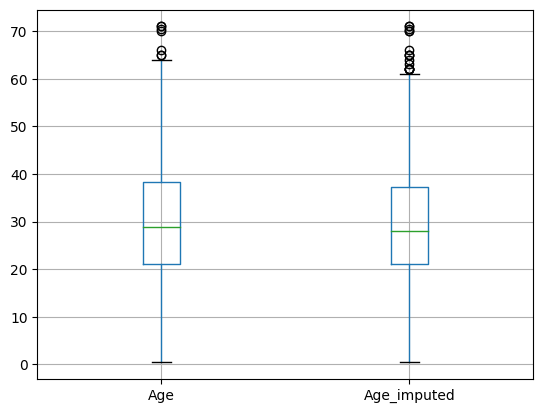

In [26]:
X_train[['Age', 'Age_imputed']].boxplot()
plt.show()

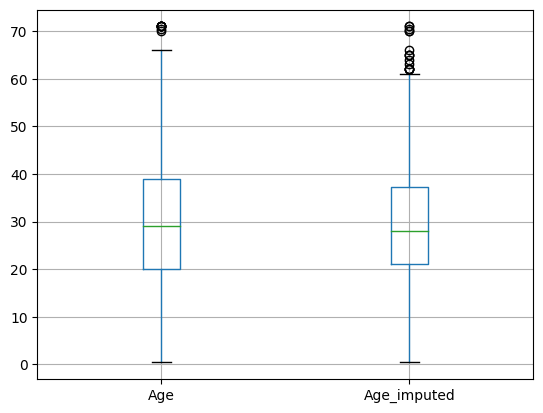

In [ ]:
# Impute missing Age values row by row using Fare as random state
for idx in X_train[X_train['Age'].isnull()].index:
	fare_value = int(X_train.loc[idx, 'Fare'])
	sampled_value = X_train['Age'].dropna().sample(1, random_state=fare_value).values[0]
	X_train.loc[idx, 'Age'] = sampled_value

# Example for a single observation
fare_value = int(X_train.loc[5, 'Fare'])
sampled_value = X_train['Age'].dropna().sample(1, random_state=fare_value).values[0]
X_train.loc[5, 'Age'] = sampled_value
X_train[['Age', 'Age_imputed']].boxplot()
plt.show()


# random state based on fare to ensure reproducibility
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

# Categorical data

In [42]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [43]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [44]:
X = data
y = data['SalePrice']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [46]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [47]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
585,Gd,TA,369900,TA,Gd
130,Gd,TA,226000,TA,Gd
103,NaN,TA,198900,TA,NaN
451,TA,TA,280000,TA,TA
368,Gd,TA,132000,TA,Gd


In [48]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\dearm\AppData\Local\Temp\ipykernel_13624\856878696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
C:\Users\dearm\AppData\Local\Temp\ipykernel_13624\856878696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
C:\Users\dearm\AppData\Local\Temp\ipykernel_13624\856878696.py:4: SettingWithCopyWarning: 
A va

In [ ]:
# Distribution of original categories
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [50]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.037671
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [56]:
# Distribution of original categories
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.494863
TA,0.412439,0.414384
Fa,0.040917,0.040240
Po,0.027823,0.026541
Ex,0.024550,0.023973


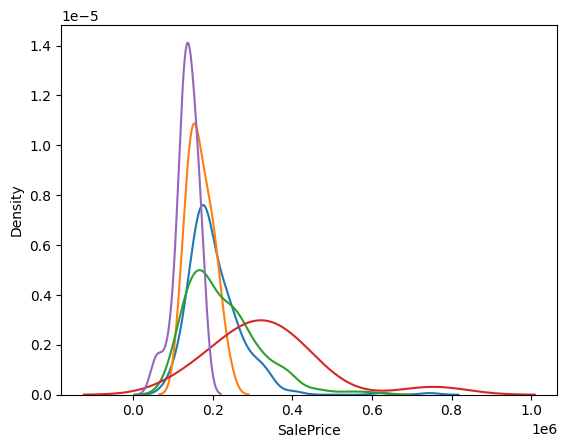

In [57]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

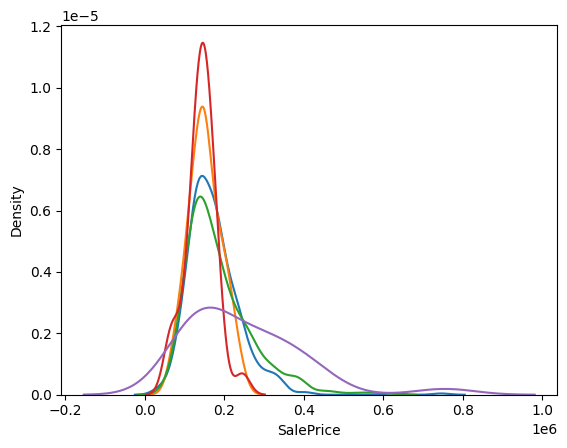

In [58]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)
plt.show()